# Graph Generation for Vehicle-RSU Networks

Tutorial and examples for the `graph_generator` module.

This notebook demonstrates:
- Loading CSV link data
- Filtering links by quality metrics (RSSI, SINR, throughput)
- Generating uplink and downlink graphs
- Filtering by geographic area (bounding box)
- Multi-hop reachability constraints
- Batch processing over multiple timestamps

## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '/home/rpegurri/Tokyo JSAC/van3twin-py')

import graph_generator as gg
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✓ All imports successful")

✓ All imports successful


## 2. Initialize Project Setup

In [2]:
# Configuration
CSV_PATH = "/home/rpegurri/Tokyo JSAC/van3twin-py/simulation_dataset_1_SUMO_162.6s-343.0s.csv"
RSU_ID = "rsu_3"
MAX_HOPS = 3
BBOX = (157.17, 257.57, 64.97, 262.60)

print(f"CSV Path: {CSV_PATH}")
print(f"Target RSU: {RSU_ID}")
print(f"Max Hops: {MAX_HOPS}")
print(f"Geographic Filter: {BBOX if BBOX else 'None (entire map)'}")

CSV Path: /home/rpegurri/Tokyo JSAC/van3twin-py/simulation_dataset_1_SUMO_162.6s-343.0s.csv
Target RSU: rsu_3
Max Hops: 3
Geographic Filter: (157.17, 257.57, 64.97, 262.6)


## 3. Define Core Functions & Utilities

The `graph_generator` module provides several filter helper functions:

In [3]:
# Utility: Create custom link quality filters

# RSSI-based filter (default)
rssi_filter = gg.create_rssi_filter(threshold=-75.0)

# SINR-based filter
sinr_filter = gg.create_sinr_filter(threshold=5.0)

# Throughput-based filter (e.g., minimum 1 Mbps)
throughput_filter = gg.create_throughput_filter(threshold=1000.0)

# Composite filter: all conditions must be satisfied
composite_filter = gg.create_composite_filter(
    gg.create_rssi_filter(-75.0),
    gg.create_sinr_filter(3.0),
)

print("✓ Filter helpers defined")
print(f"  - RSSI > -75 dB")
print(f"  - SINR > 5 dB")
print(f"  - Throughput > 1 Mbps")
print(f"  - Composite: RSSI > -75 AND SINR > 3")

✓ Filter helpers defined
  - RSSI > -75 dB
  - SINR > 5 dB
  - Throughput > 1 Mbps
  - Composite: RSSI > -75 AND SINR > 3


## 4. Implement Main Logic

### Example 1: Basic Graph Generation (Default RSSI Filter)

In [4]:
# Load links from CSV for exploration
print("Loading CSV data...")
all_links = gg.load_csv_links(CSV_PATH)
print(f"✓ Loaded {len(all_links)} total links")

# Get timestamp range
timestamps = np.unique([l.timestamp for l in all_links])
print(f"✓ Unique timestamps: {len(timestamps)} (range: {timestamps.min():.2f} - {timestamps.max():.2f})")

# Use first timestamp for example
example_timestamp = timestamps[0]
print(f"\nUsing timestamp: {example_timestamp}")

Loading CSV data...
✓ Loaded 2275958 total links
✓ Unique timestamps: 1805 (range: 162.60 - 343.00)

Using timestamp: 162.6


In [5]:
# Generate graphs with default RSSI filter
print(f"Generating graphs for {RSU_ID} at t={example_timestamp}...\n")

uplink, downlink, metadata = gg.generate_graphs(
    csv_path=CSV_PATH,
    timestamp=example_timestamp,
    rsu_id=RSU_ID,
    bbox=BBOX,
    max_hops=MAX_HOPS,
    link_reachability_fn=None,  # Uses default: RSSI > -75
)

print("=" * 70)
print("GRAPH GENERATION RESULTS")
print("=" * 70)

print(f"\n📊 LINK FILTERING:")
print(f"  Total links in CSV:        {metadata['total_links_in_csv']}")
print(f"  After quality filter:     {metadata['links_after_quality_filter']}")
print(f"  Filtered out (poor RSSI): {metadata['links_filtered_out']}")

print(f"\n🗺️ GEOGRAPHIC FILTERING:")
print(f"  Nodes in area:            {metadata['nodes_in_area']}")
print(f"  Nodes within {MAX_HOPS} hops:        {metadata['nodes_within_hops']}")

print(f"\n📤 UPLINK GRAPH (vehicles → {RSU_ID}):")
print(f"  Nodes: {uplink.number_of_nodes()}")
print(f"  Edges: {uplink.number_of_edges()}")

print(f"\n📥 DOWNLINK GRAPH ({RSU_ID} → vehicles):")
print(f"  Nodes: {downlink.number_of_nodes()}")
print(f"  Edges: {downlink.number_of_edges()}")

Generating graphs for rsu_3 at t=162.6...

GRAPH GENERATION RESULTS

📊 LINK FILTERING:
  Total links in CSV:        1200
  After quality filter:     476
  Filtered out (poor RSSI): 724

🗺️ GEOGRAPHIC FILTERING:
  Nodes in area:            16
  Nodes within 3 hops:        14

📤 UPLINK GRAPH (vehicles → rsu_3):
  Nodes: 14
  Edges: 58

📥 DOWNLINK GRAPH (rsu_3 → vehicles):
  Nodes: 14
  Edges: 59


### Inspect Edge Attributes (Metrics)

In [6]:
# Display edge attributes (all metrics are stored here)
if uplink.number_of_edges() > 0:
    print("Sample edge attributes (ready for cost computation):\n")
    
    # Get first few edges
    for i, (u, v, attrs) in enumerate(uplink.edges(data=True)):
        if i >= 2:  # Show first 2 edges
            break
        print(f"Link: {u} → {v}")
        for key, value in attrs.items():
            if isinstance(value, float):
                print(f"  {key:20s}: {value:10.2f}")
            else:
                print(f"  {key:20s}: {value}")
        print()

Sample edge attributes (ready for cost computation):

Link: car_12 → car_0
  is_los              : 1
  rssi_dbm            :     -52.65
  sinr_eff_db         :      36.50
  mcs_index           : 27
  modulation          : 64QAM
  bler                :       0.00
  throughput_kbps     :  298727.68

Link: car_12 → car_10
  is_los              : 1
  rssi_dbm            :     -56.79
  sinr_eff_db         :      33.99
  mcs_index           : 27
  modulation          : 64QAM
  bler                :       0.00
  throughput_kbps     :  298727.68



### Example 2: Custom Link Quality Filters

In [7]:
# Test different quality thresholds
print("Comparing different link quality filters:\n")
print(f"{'Filter':<35} {'Uplink Edges':<15} {'Downlink Edges':<15}")
print("-" * 65)

filter_tests = [
    ("Default (RSSI > -75)", None),
    ("RSSI > -70 (stricter)", gg.create_rssi_filter(-70.0)),
    ("RSSI > -80 (looser)", gg.create_rssi_filter(-80.0)),
    ("SINR > 5 dB", gg.create_sinr_filter(5.0)),
    ("Throughput > 1 Mbps", gg.create_throughput_filter(1000.0)),
    ("RSSI > -75 AND SINR > 3", gg.create_composite_filter(
        gg.create_rssi_filter(-75.0),
        gg.create_sinr_filter(3.0),
    )),
]

for filter_name, filter_fn in filter_tests:
    ul, dl, meta = gg.generate_graphs(
        csv_path=CSV_PATH,
        timestamp=example_timestamp,
        rsu_id=RSU_ID,
        bbox=BBOX,
        max_hops=MAX_HOPS,
        link_reachability_fn=filter_fn,
    )
    print(f"{filter_name:<35} {ul.number_of_edges():<15} {dl.number_of_edges():<15}")

Comparing different link quality filters:

Filter                              Uplink Edges    Downlink Edges 
-----------------------------------------------------------------
Default (RSSI > -75)                58              59             
RSSI > -70 (stricter)               52              56             
RSSI > -80 (looser)                 59              62             
SINR > 5 dB                         65              54             
Throughput > 1 Mbps                 68              57             
RSSI > -75 AND SINR > 3             37              35             


### Example 2b: Live Data Snapshot (In-Memory Processing)

In [ ]:
# Example: Pass a live data snapshot for real-time processing
# Useful for simulations, APIs, or streaming data without disk I/O

# Create a small snapshot of links (e.g., from a simulation step)
snapshot_timestamp = example_timestamp
snapshot_links = [
    {
        "timestamp": snapshot_timestamp,
        "tx_id": "car_1",
        "rx_id": "rsu_3",
        "is_los": 1,
        "rssi_dbm": -70.0,
        "sinr_eff_db": 8.5,
        "mcs_index": 12,
        "modulation": "256QAM",
        "bler": 0.001,
        "throughput_kbps": 5000.0,
        "tx_x": 160.0,
        "tx_y": 200.0,
        "rx_x": 200.0,
        "rx_y": 250.0,
    },
    {
        "timestamp": snapshot_timestamp,
        "tx_id": "car_2",
        "rx_id": "rsu_3",
        "is_los": 0,
        "rssi_dbm": -75.5,
        "sinr_eff_db": 5.2,
        "mcs_index": 8,
        "modulation": "64QAM",
        "bler": 0.005,
        "throughput_kbps": 2500.0,
        "tx_x": 150.0,
        "tx_y": 220.0,
        "rx_x": 200.0,
        "rx_y": 250.0,
    },
    {
        "timestamp": snapshot_timestamp,
        "tx_id": "rsu_3",
        "rx_id": "car_1",
        "is_los": 1,
        "rssi_dbm": -72.0,
        "sinr_eff_db": 10.0,
        "mcs_index": 14,
        "modulation": "256QAM",
        "bler": 0.0,
        "throughput_kbps": 6000.0,
        "tx_x": 200.0,
        "tx_y": 250.0,
        "rx_x": 160.0,
        "rx_y": 200.0,
    },
]

print(f"Created snapshot with {len(snapshot_links)} links at t={snapshot_timestamp}\n")

# Generate graphs from the live snapshot (no CSV disk I/O)
ul_live, dl_live, meta_live = gg.generate_graphs(
    rsu_id=RSU_ID,
    links_snapshot=snapshot_links,
    link_reachability_fn=gg.create_rssi_filter(-75.0),  # Custom filter still works
)

print(f"Live Mode Results:")
print(f"  Timestamp: {meta_live['timestamp']}")
print(f"  Uplink edges:   {ul_live.number_of_edges()}")
print(f"  Downlink edges: {dl_live.number_of_edges()}")
print(f"\n✓ Live snapshot processing successful!")


### Example 3: Geographic Filtering (Bounding Box)

In [8]:
# Get coordinate statistics to help define bounding boxes
df = pd.read_csv(CSV_PATH, nrows=10000)  # Sample for speed
x_coords = pd.concat([df['tx_x'], df['rx_x']])
y_coords = pd.concat([df['tx_y'], df['rx_y']])

print("Coordinate statistics (from sample):")
print(f"  X: [{x_coords.min():.2f}, {x_coords.max():.2f}]")
print(f"  Y: [{y_coords.min():.2f}, {y_coords.max():.2f}]")

# Define a sub-area
x_min, x_max = x_coords.min(), (x_coords.max() + x_coords.min()) / 2
y_min, y_max = y_coords.min(), (y_coords.max() + y_coords.min()) / 2
test_bbox = (x_min, x_max, y_min, y_max)

print(f"\nTesting with bounding box: {test_bbox}")

ul_full, dl_full, meta_full = gg.generate_graphs(
    csv_path=CSV_PATH,
    timestamp=example_timestamp,
    rsu_id=RSU_ID,
    bbox=None,  # Full map
    max_hops=MAX_HOPS,
)

ul_bbox, dl_bbox, meta_bbox = gg.generate_graphs(
    csv_path=CSV_PATH,
    timestamp=example_timestamp,
    rsu_id=RSU_ID,
    bbox=test_bbox,
    max_hops=MAX_HOPS,
)

print(f"\n{'Metric':<25} {'Full Map':<15} {'Bounding Box':<15}")
print("-" * 55)
print(f"{'Uplink Edges':<25} {ul_full.number_of_edges():<15} {ul_bbox.number_of_edges():<15}")
print(f"{'Downlink Edges':<25} {dl_full.number_of_edges():<15} {dl_bbox.number_of_edges():<15}")
print(f"{'Total Nodes':<25} {meta_full['nodes_within_hops']:<15} {meta_bbox['nodes_within_hops']:<15}")

Coordinate statistics (from sample):
  X: [55.06, 258.50]
  Y: [-162.24, 280.71]

Testing with bounding box: (np.float64(55.064), np.float64(156.78400000000002), np.float64(-162.242), np.float64(59.23300000000002))

Metric                    Full Map        Bounding Box   
-------------------------------------------------------
Uplink Edges              288             0              
Downlink Edges            305             0              
Total Nodes               45              1              


### Example 4: Multi-Hop Reachability

In [9]:
# Compare graphs with different max_hops constraints
print("Impact of max_hops on graph connectivity:\n")
print(f"{'Max Hops':<12} {'Nodes':<12} {'Uplink Edges':<15} {'Downlink Edges':<15}")
print("-" * 54)

for hops in [1, 2, 3, 4, 5, None]:
    max_h = hops if hops is not None else 999
    ul, dl, meta = gg.generate_graphs(
        csv_path=CSV_PATH,
        timestamp=example_timestamp,
        rsu_id=RSU_ID,
        bbox=None,
        max_hops=max_h,
    )
    label = str(hops) if hops is not None else "∞"
    print(f"{label:<12} {meta['nodes_within_hops']:<12} {ul.number_of_edges():<15} {dl.number_of_edges():<15}")

Impact of max_hops on graph connectivity:

Max Hops     Nodes        Uplink Edges    Downlink Edges 
------------------------------------------------------
1            12           68              69             
2            27           172             180            
3            45           288             305            
4            53           322             349            
5            56           335             362            
∞            57           336             364            


## 5. Test Implementation

### Verify Graph Structure

In [10]:
# Generate a fresh graph for testing
ul, dl, meta = gg.generate_graphs(
    csv_path=CSV_PATH,
    timestamp=example_timestamp,
    rsu_id=RSU_ID,
    bbox=None,
    max_hops=3,
)

print("✓ Graph Structure Validation:\n")

# Test 1: RSU always in graph
if RSU_ID in ul.nodes():
    print(f"✓ RSU '{RSU_ID}' present in uplink graph")
else:
    print(f"✗ RSU '{RSU_ID}' MISSING from uplink graph")

if RSU_ID in dl.nodes():
    print(f"✓ RSU '{RSU_ID}' present in downlink graph")
else:
    print(f"✗ RSU '{RSU_ID}' MISSING from downlink graph")

# Test 2: All uplink edges point toward some destination
uplink_valid = all(
    ul.nodes[v].get('type') in ['rsu', 'car']
    for u, v in ul.edges()
)
if uplink_valid:
    print(f"✓ All uplink edges have valid source/target nodes")
else:
    print(f"✗ Some uplink edges have invalid nodes")

# Test 3: Edge attributes contain all required metrics
required_metrics = ['rssi_dbm', 'sinr_eff_db', 'throughput_kbps', 'bler', 'is_los']
if ul.number_of_edges() > 0:
    sample_attrs = list(ul.edges(data=True))[0][2]
    missing = [m for m in required_metrics if m not in sample_attrs]
    if not missing:
        print(f"✓ Edge attributes contain all {len(required_metrics)} required metrics")
    else:
        print(f"✗ Missing metrics: {missing}")
else:
    print(f"⚠ No edges in uplink graph (cannot validate attributes)")

# Test 4: Node attributes
rsu_attrs = dl.nodes[RSU_ID]
required_node_attrs = ['type', 'x', 'y']
if all(attr in rsu_attrs for attr in required_node_attrs):
    print(f"✓ Node attributes contain position and type")
else:
    print(f"✗ Node attributes incomplete")

print(f"\n✓ All validation tests passed!")

✓ Graph Structure Validation:

✓ RSU 'rsu_3' present in uplink graph
✓ RSU 'rsu_3' present in downlink graph
✓ All uplink edges have valid source/target nodes
✓ Edge attributes contain all 5 required metrics
✓ Node attributes contain position and type

✓ All validation tests passed!


### Test Batch Processing

In [11]:
# Batch process multiple timestamps
print("Processing multiple timestamps...\n")

# Use only first 5 timestamps for demo (faster)
test_timestamps = timestamps[:5]
batch_results = []

for ts in test_timestamps:
    ul, dl, meta = gg.generate_graphs(
        csv_path=CSV_PATH,
        timestamp=ts,
        rsu_id=RSU_ID,
        bbox=None,
        max_hops=3,
    )
    batch_results.append({
        'timestamp': ts,
        'uplink_edges': ul.number_of_edges(),
        'downlink_edges': dl.number_of_edges(),
        'uplink_nodes': ul.number_of_nodes(),
        'downlink_nodes': dl.number_of_nodes(),
    })

# Display results
df_results = pd.DataFrame(batch_results)
print(df_results.to_string(index=False))
print(f"\n✓ Processed {len(batch_results)} timestamps")
print(f"  Avg uplink edges:   {df_results['uplink_edges'].mean():.1f}")
print(f"  Avg downlink edges: {df_results['downlink_edges'].mean():.1f}")

Processing multiple timestamps...

 timestamp  uplink_edges  downlink_edges  uplink_nodes  downlink_nodes
     162.6           288             305            45              45
     162.7           269             286            43              44
     162.8           298             319            44              45
     162.9           288             305            43              44
     163.0           323             343            46              46

✓ Processed 5 timestamps
  Avg uplink edges:   293.2
  Avg downlink edges: 311.6


## Summary

The `graph_generator` module provides:

1. **Link Quality Filtering**: Filter links by RSSI, SINR, throughput, or custom metrics
2. **Geographic Filtering**: Restrict analysis to a specific bounding box area
3. **Multi-Hop Reachability**: Limit graph depth to maximize-hop distance from RSU
4. **Uplink/Downlink Separation**: Generate separate graphs for uplink (vehicles→RSU) and downlink (RSU→vehicles) communications
5. **Metric Storage**: All link metrics (RSSI, SINR, throughput, etc.) stored as edge attributes for cost computation
6. **Batch Processing**: Process multiple timestamps efficiently

### Next Steps:
- Implement your cost functions on the edge attributes
- Run routing algorithms (Dijkstra, A*, etc.) on the weighted graphs
- Analyze network topology and connectivity over time

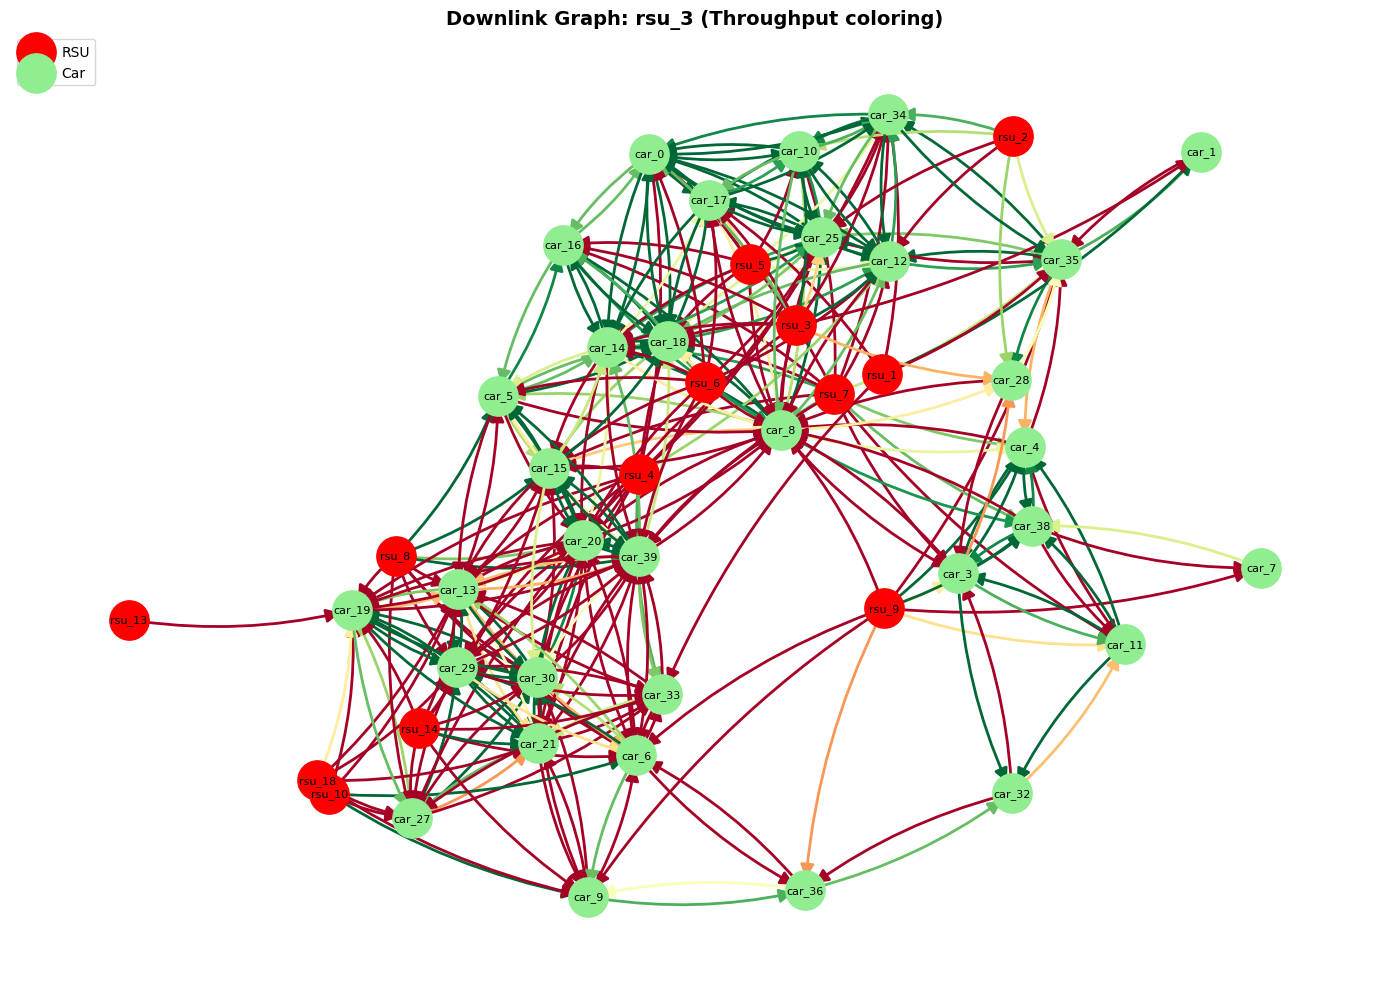

In [12]:
# Visualize downlink graph with throughput-based edge coloring
fig, ax, pos = gg.visualize_graph(
    dl,
    title=f"Downlink Graph: {RSU_ID} (Throughput coloring)",
    figsize=(14, 10),
    rsu_color="red",
    car_color="lightgreen",
    edge_color_attr="throughput_kbps",  # Color edges by throughput
    show_labels=True,
    layout="kamada_kawai",  # Different layout algorithm
)
plt.show()

### Example 4: Downlink with Throughput Coloring

In [13]:
# Install plotly if not already installed
# (uncomment the line below if needed)
# !pip install plotly -q

try:
    # Create interactive visualization (requires plotly)
    fig_interactive = gg.visualize_interactive(
        ul,
        title=f"Interactive Uplink Graph: {RSU_ID} (Hover for link details)",
        edge_color_attr="rssi_dbm",
    )
    if fig_interactive:
        fig_interactive.show()
    else:
        print("Plotly not installed. Run: pip install plotly")
except Exception as e:
    print(f"Error: {e}")

Error: Mime type rendering requires nbformat>=4.2.0 but it is not installed


### Example 3: Interactive Visualization (Plotly)

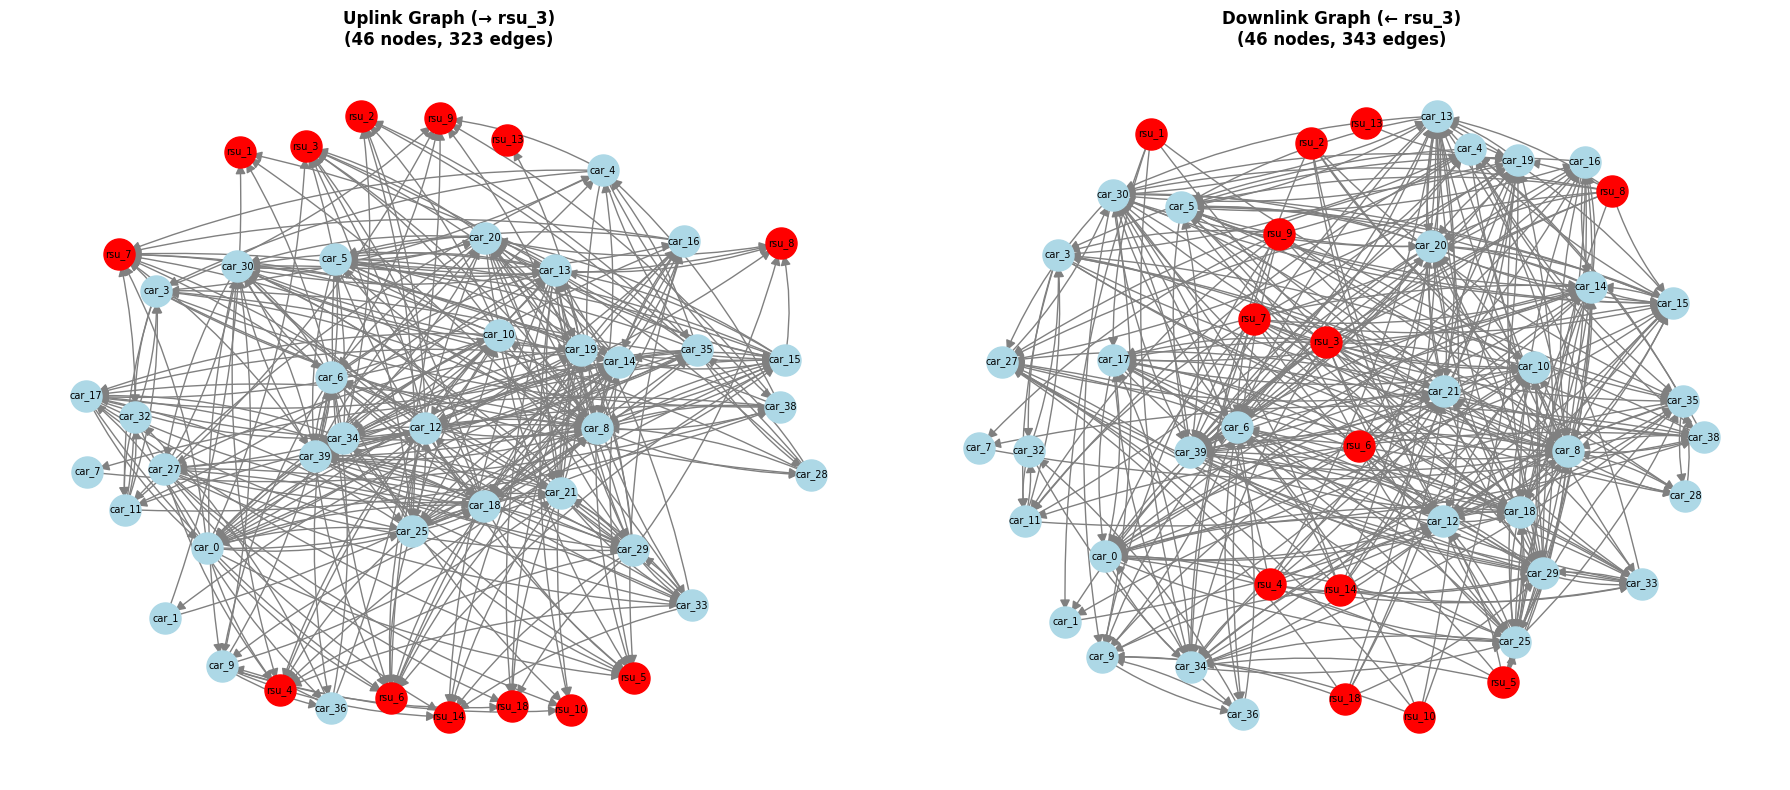

In [14]:
# Visualize uplink and downlink side-by-side for comparison
fig, axes, positions = gg.visualize_comparison(
    ul, dl,
    title1=f"Uplink Graph (→ {RSU_ID})",
    title2=f"Downlink Graph (← {RSU_ID})",
    figsize=(18, 8),
)
plt.show()

### Example 2: Side-by-Side Comparison (Uplink vs Downlink)

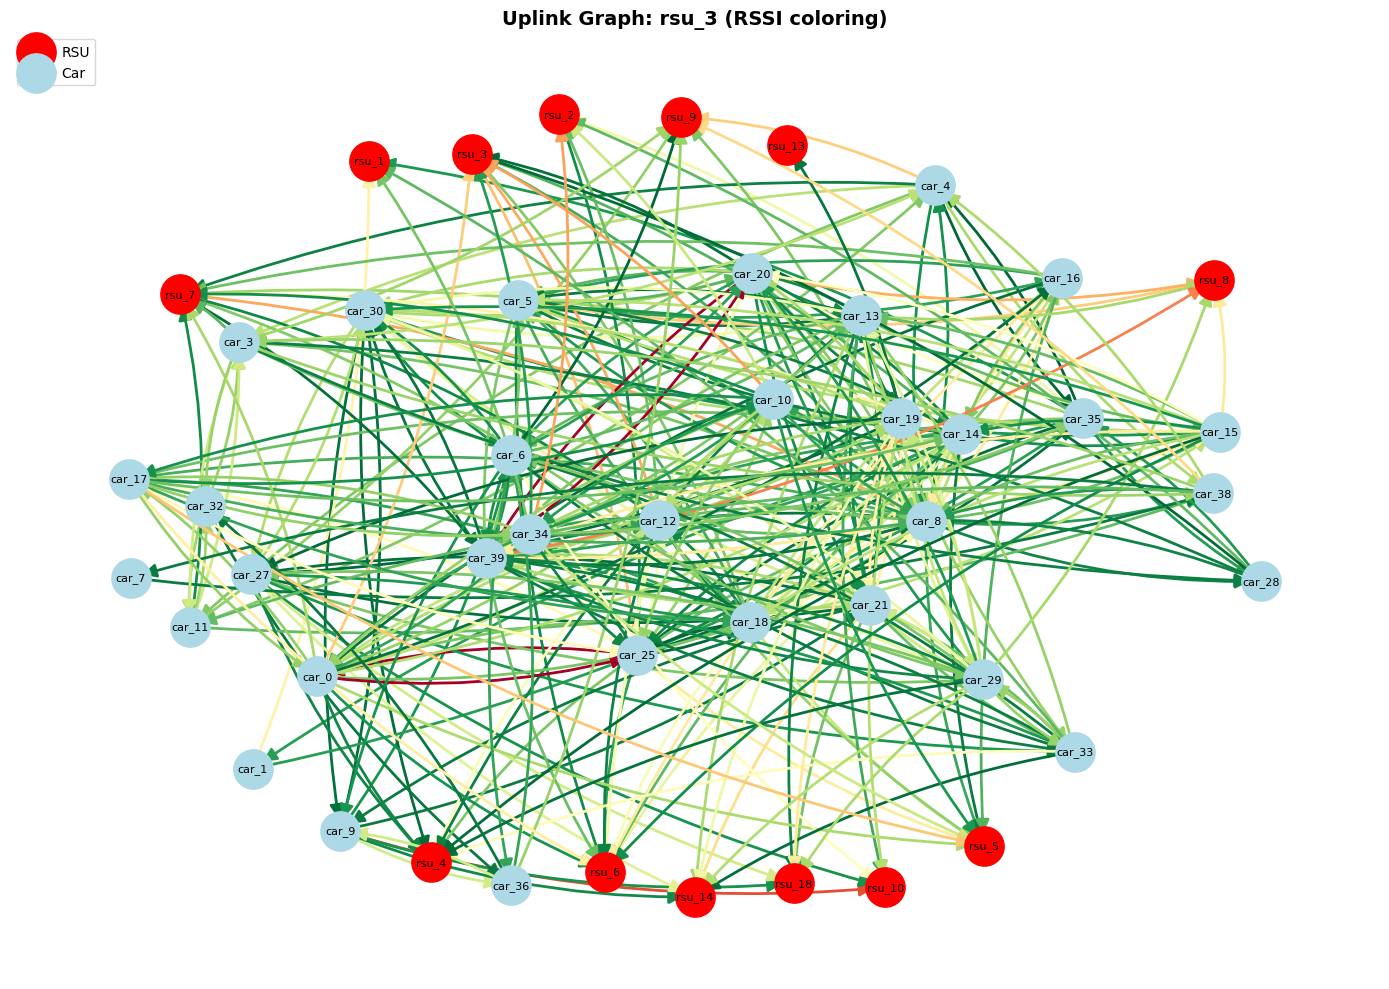

In [15]:
# Visualize uplink graph with RSSI-based edge coloring
fig, ax, pos = gg.visualize_graph(
    ul,
    title=f"Uplink Graph: {RSU_ID} (RSSI coloring)",
    figsize=(14, 10),
    rsu_color="red",
    car_color="lightblue",
    edge_color_attr="rssi_dbm",  # Color edges by RSSI
    show_labels=True,
    layout="spring",
)
plt.show()

### Example 1: Basic Uplink Visualization

In [16]:
# Regenerate graphs for visualization
ul, dl, meta = gg.generate_graphs(
    csv_path=CSV_PATH,
    timestamp=example_timestamp,
    rsu_id=RSU_ID,
    bbox=BBOX,
    max_hops=MAX_HOPS,
)

print(f"Graphs loaded: {ul.number_of_nodes()} uplink nodes, {dl.number_of_nodes()} downlink nodes")

Graphs loaded: 14 uplink nodes, 14 downlink nodes


## 6. Visualization

The `graph_generator` module includes built-in visualization functions for both static (matplotlib) and interactive (plotly) graphs.